# `CTViz`
This notebook is intended to be used for inspecting results.

It should follow `./scripts/train_scvi.py`, `./scripts/cluster`, and `./scripts/cytetype.predict.py`.

In [2]:
# Import libraries
from pathlib import Path
import scanpy as sc
import matplotlib.pyplot as plt
from cytetype import CyteType

## Model Training Plots

In [3]:
# Import libraries
import scvi
import seaborn as sns

/Users/otodreas/Desktop/Work/Nygen/Interview/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# Load model
model = scvi.model.SCVI.load(Path.cwd().parent / "models" / "scvi3", adata=adata)

INFO     File /Users/otodreas/Desktop/Work/Nygen/Interview/models/scvi3/model.pt already downloaded                


/Users/otodreas/Desktop/Work/Nygen/Interview/.venv/lib/python3.12/site-packages/scvi/model/base/_base_model.py:862: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(


In [13]:
# Assign model history to variable
hist = model.history


# Set matplotlib aesthetics
def plot_metric(train_key, val_key, title, ylabel):
    plt.figure(figsize=(6, 4))
    plt.plot(hist[train_key], label="train")
    plt.plot(hist[val_key], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

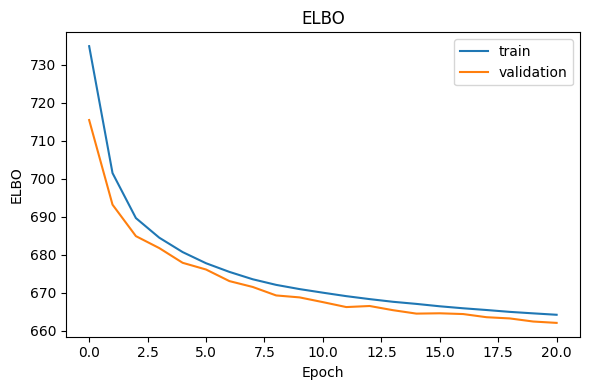

In [14]:
# Negative ELBO (Evidence lower bound)
if "elbo_train" in hist:
    plot_metric("elbo_train", "elbo_validation", "ELBO", "ELBO")

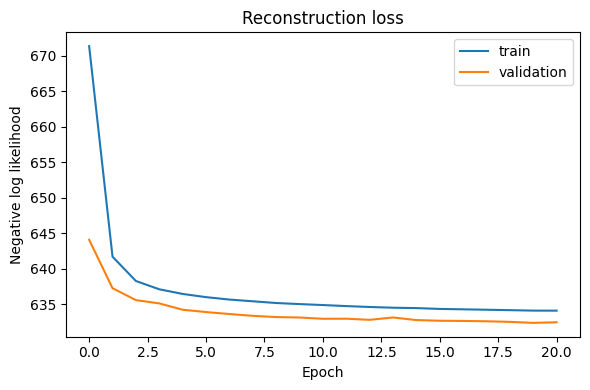

In [15]:
# Reconstruction loss
plot_metric(
    "reconstruction_loss_train",
    "reconstruction_loss_validation",
    "Reconstruction loss",
    "Negative log likelihood",
)

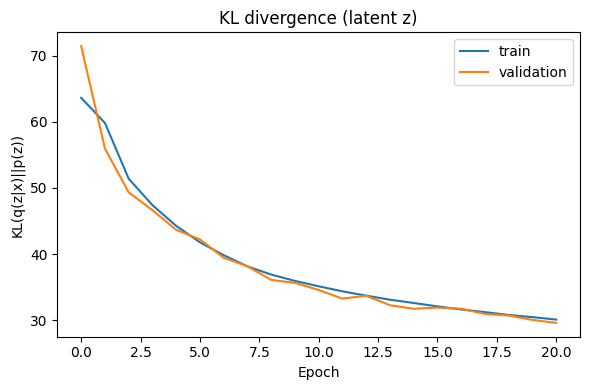

In [16]:
# Local KL divergence
plot_metric(
    "kl_local_train",
    "kl_local_validation",
    "KL divergence (latent z)",
    "KL(q(z|x)||p(z))",
)

## CyteType Analysis
[Report](https://prod.cytetype.nygen.io/report/2b7c8134-bc7b-4c8f-b5e6-a2bdc1d9abf5)

In [6]:
# Load adata
adata = sc.read(
    filename=Path.cwd().parent / "data" / "monocyte_dendritic_cytetype.h5ad"
)
adata

AnnData object with n_obs × n_vars = 389187 × 1500
    obs: 'cohort.cohortGuid', 'subject.subjectGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid', 'subject.ageAtFirstDraw', 'subject.race', 'subject.ethnicity', 'subject.cmv', 'sample.visitName', 'sample.subjectAgeAtDraw', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_reads', 'n_umis', 'n_genes', 'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1', 'predicted_AIFI_L1', 'AIFI_L2', 'predicted_AIFI_L2', 'AIFI_L3', 'predicted_AIFI_L3', 'tissue_ontology_term_id', 'tissue_type', 'suspension_type', 'assay_ontology_term_id', 'sex_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', '_scvi_batch', '_scvi_labels', 'clusters', 'cytetype_annotation_clusters', 'cytetype_cellO

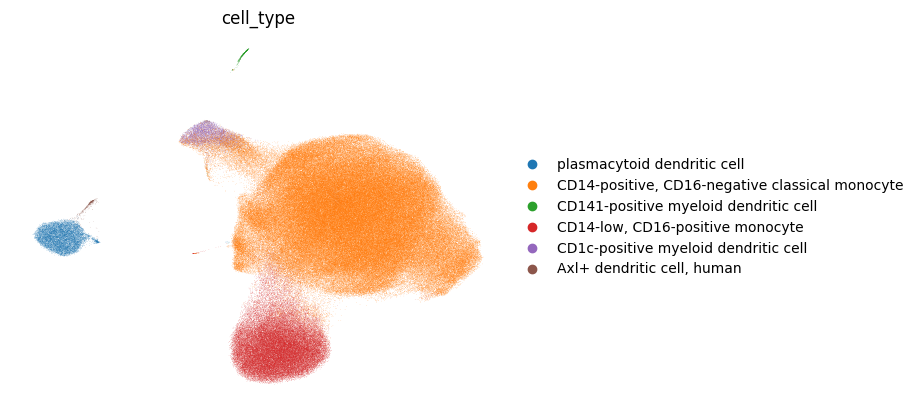

In [7]:
# Plot cell type UMAP
sc.pl.umap(adata, color=["cell_type"], frameon=False)

Note that during clustering, I used the default number of clusters. Had I had more time I would have also generated results with different numbers of clusters, but for now I left it as the default. It was interesting to see that even though the number of clusters are different in the two UMAP plots, there is still a lot of agreement between the plots.

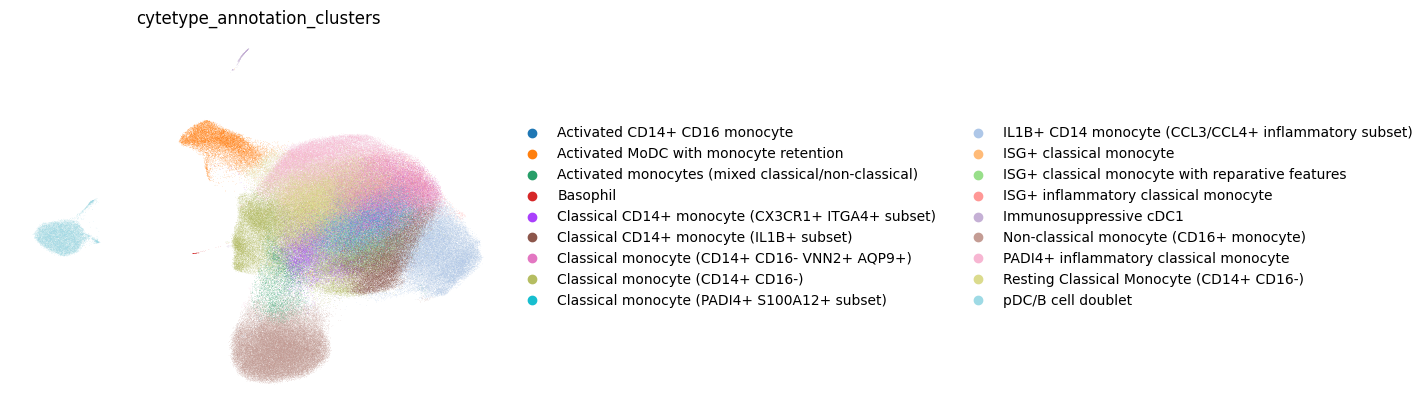

In [8]:
# Plot CyteType predicted cell type UMAP
sc.pl.umap(adata, color="cytetype_annotation_clusters", frameon=False)

In [9]:
# View full results
adata.uns["cytetype_results"]

{'job_id': '2b7c8134-bc7b-4c8f-b5e6-a2bdc1d9abf5',
 'result': '{"annotations": [{"clusterId": "0", "annotation": "IL1B+ CD14 monocyte (CCL3/CCL4+ inflammatory subset)", "ontologyTerm": "CD14-positive, CD16-negative classical monocyte", "ontologyTermID": "CL_0002057", "granularAnnotation": "IL1B+ CD14+ classical monocytes with NF-\\u03baB-driven inflammatory activation (TNFAIP3+ NFKBIA+) expressing CCL3/CCL4 chemokines and co-expressing CD163 in a regulated hybrid inflammatory/repair state (homogeneous population)", "cellState": "Activated and inflammatory", "justification": "", "supportingMarkers": [], "conflictingMarkers": [], "missingExpression": "", "unexpectedExpression": ""}, {"clusterId": "1", "annotation": "Classical CD14+ monocyte (IL1B+ subset)", "ontologyTerm": "CD14-positive, CD16-negative classical monocyte", "ontologyTermID": "CL_0002057", "granularAnnotation": "Classical CD14+ monocyte (IL1B+ subset) with inflammatory activation state expressing immediate-early genes FOSB

In [11]:
adata.obs["cytetype_cellState_clusters"].head()

barcodes
18b59c0e3e7711ee820d16b6deab1851    Activated and inflammatory
722c1e863e7f11eeba8f921887f49d91                       Resting
c95597f03e7f11eeba8f921887f49d91    Activated and inflammatory
c95543363e7f11eeba8f921887f49d91    Activated and inflammatory
16c2dcaa3e8011eeba8f921887f49d91                       Resting
Name: cytetype_cellState_clusters, dtype: category
Categories (14, object): ['Activated and antiviral primed', 'Activated and antiviral-responsive', 'Activated and immunosuppressive', 'Activated and inflammatory', ..., 'Inflammatory activated', 'Metabolically active and immunoregulatory', 'Neutrophil-like antimicrobial and metabolical..., 'Resting']